In [1]:
# ============================================================
# Cell 1: 設定 — ここだけ変えれば全セルが追従する
# ============================================================
from pathlib import Path

CASE_NAME    = "ranch_01" 
TERRAIN_PLY  = f"cases/{CASE_NAME}/terrain.ply"
TREE_GLB     = "assets/tree.glb"

# ── 観測点(ポール)構成 ──────────────────────────────────────
N_POLES          = 15    # 設置するポール数
FIXED_PER_POLE   = 4     # ポール1本あたりの固定カメラ数 (均等方位)
PTZ_PER_POLE     = 2     # ポール1本あたりのPTZカメラ数
POLE_HEIGHT_MIN  = 2.5   # ポール最低高さ [m] (急斜面・木取付等)
POLE_HEIGHT_MAX  = 3.0   # ポール最大高さ [m] (平地標準)

# ── カメラパラメータ ─────────────────────────────────────────
IMAGE_W          = 1920
IMAGE_H          = 1080
FX               = 1200.0
FY               = 1200.0
FIXED_TILT_DEG   = -20.0   # 固定カメラ俯角 (負=下向き)
FIXED_FOV_H      = 90.0    # 固定カメラ水平FOV
PTZ_FOV_H        = 60.0    # PTZ水平FOV
MAX_VIS_RANGE    = 150.0   # 最大可視距離 [m]

# ── 地形解析パラメータ ───────────────────────────────────────
SLOPE_THRESHOLD_DEG = 25.0
RIDGE_PERCENTILE    = 85.0
VALLEY_PERCENTILE   = 15.0

# ── 最適化パラメータ ─────────────────────────────────────────
N_RAY_SAMPLES  = 256
SA_ITERATIONS  = 500
# ゾーン重み: A=農場外(禁止), B=フェンス帯, C=内部, D=建物周辺
# farm_boundary.json がない場合は "1"/"2"/"3" フォールバック
ZONE_WEIGHTS = {
    "A": 0.0, "B": 1.5, "C": 2.0, "D": 1.8,
    "1": 1.0, "2": 1.5, "3": 2.0,
}

# ── 農場境界ゾーン設定 ───────────────────────────────────────
# farm_boundary.json が存在する場合のみ有効
FARM_BOUNDARY_JSON   = Path(f"cases/{CASE_NAME}/farm_boundary.json")
FENCE_ZONE_WIDTH     = 20.0   # Zone B: 境界から内側の幅 [m]
BUILDING_ZONE_RADIUS = 10.0   # Zone D: 建物フットプリントからの半径 [m]

# ── 正解点群 ─────────────────────────────────────────────────
GT_N_POINTS = 100_000

# ── 出力先 ───────────────────────────────────────────────────
CASE_DIR   = Path(f"cases/{CASE_NAME}")
CASE_DIR.mkdir(parents=True, exist_ok=True)
POSES_JSON = CASE_DIR / "camera_poses.json"
GT_PLY     = CASE_DIR / "terrain_gt.ply"
COLMAP_DIR = CASE_DIR / "colmap_input" / "sparse" / "0"

N_CAMERAS_TOTAL = N_POLES * (FIXED_PER_POLE + PTZ_PER_POLE)
print(f"Case        : {CASE_NAME}")
print(f"Terrain     : {TERRAIN_PLY}")
print(f"Poles       : {N_POLES} 本  (高さ {POLE_HEIGHT_MIN}〜{POLE_HEIGHT_MAX} m)")
print(f"Cameras     : {N_POLES}poles × ({FIXED_PER_POLE}固定+{PTZ_PER_POLE}PTZ) = {N_CAMERAS_TOTAL} 台")
print(f"Farm bndry  : {'あり' if FARM_BOUNDARY_JSON.exists() else 'なし (BBoxフォールバック)'}")

Case        : ranch_01
Terrain     : cases/ranch_01/terrain.ply
Poles       : 15 本  (高さ 2.5〜3.0 m)
Cameras     : 15poles × (4固定+2PTZ) = 90 台
Farm bndry  : あり


In [2]:
! ls /workspace/cases/ranch_01/

farm_boundary.json  scene_preview.png  terrain.ply  terrain_gt.ply


Vertices : 361,201
Faces    : 720,000
Bounds   : X=[0.0, 3000.0]  Y=[0.0, 3000.0]  Z=[0.0, 116.7] m
Size     : 3000 m x 3000 m


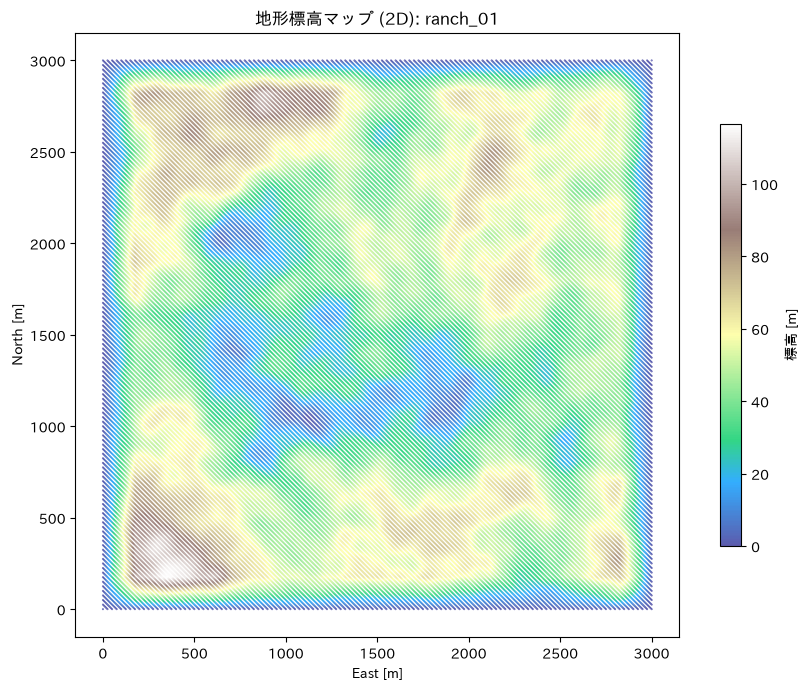

In [3]:
# ============================================================
# Cell 2: 地形読み込み・2D可視化
#   ※ 3D可視化は下部のコメントアウト欄を解除して使用
# ============================================================
import sys; sys.path.insert(0, '.')
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib  # 日本語フォント自動設定
from scripts.terrain_loader import load_terrain_as_mesh

mesh, info = load_terrain_as_mesh(TERRAIN_PLY)

print(f"Vertices : {len(mesh.vertices):,}")
print(f"Faces    : {len(mesh.faces):,}")
print(f"Bounds   : X=[{info['x_min']:.1f}, {info['x_max']:.1f}]  "
      f"Y=[{info['y_min']:.1f}, {info['y_max']:.1f}]  "
      f"Z=[{info['z_min']:.1f}, {info['z_max']:.1f}] m")
print(f"Size     : {info['width']:.0f} m x {info['height']:.0f} m")

verts = np.array(mesh.vertices)
faces = np.array(mesh.faces)
plot_step = 5  # 描画用の間引き率 (メモリ・描画負荷を抑える)

# ── 2D標高マップ (軽量) ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
pv = verts[::plot_step]
sc = ax.scatter(pv[:,0], pv[:,1], c=pv[:,2],
                cmap='terrain', s=0.2, alpha=0.8)
plt.colorbar(sc, ax=ax, label='標高 [m]', shrink=0.7)
ax.set_xlabel('East [m]'); ax.set_ylabel('North [m]')
ax.set_title(f'地形標高マップ (2D): {CASE_NAME}')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()
plt.close(fig)  # メモリ解放

# ─────────────────────────────────────────────────────────────
# 【3D可視化 — 重いので必要時のみコメントアウト解除】
# import plotly.graph_objects as go
# step = 10  # 間引き率 (1=全頂点, 10=約36k頂点)
# sv, sf = verts[::step], faces[::step]
# fig3d = go.Figure(data=[go.Mesh3d(
#     x=sv[:,0], y=sv[:,1], z=sv[:,2],
#     i=sf[:,0], j=sf[:,1], k=sf[:,2],
#     colorscale='earth', intensity=sv[:,2],
#     showscale=True, name='Terrain', opacity=0.8,
# )])
# fig3d.update_layout(
#     title=f"地形メッシュ: {CASE_NAME}",
#     scene=dict(xaxis_title='East [m]', yaxis_title='North [m]',
#                zaxis_title='Up [m]', aspectmode='data'),
#     width=900, height=600,
# )
# fig3d.show()
# ─────────────────────────────────────────────────────────────


稜線頂点数 : 54,181 / 361,201
谷底頂点数 : 54,181
急斜面頂点 : 12,682  (>25.0°)
ポール高さ : 平地=3.0m  急斜面=2.5m (傾斜で線形補間)


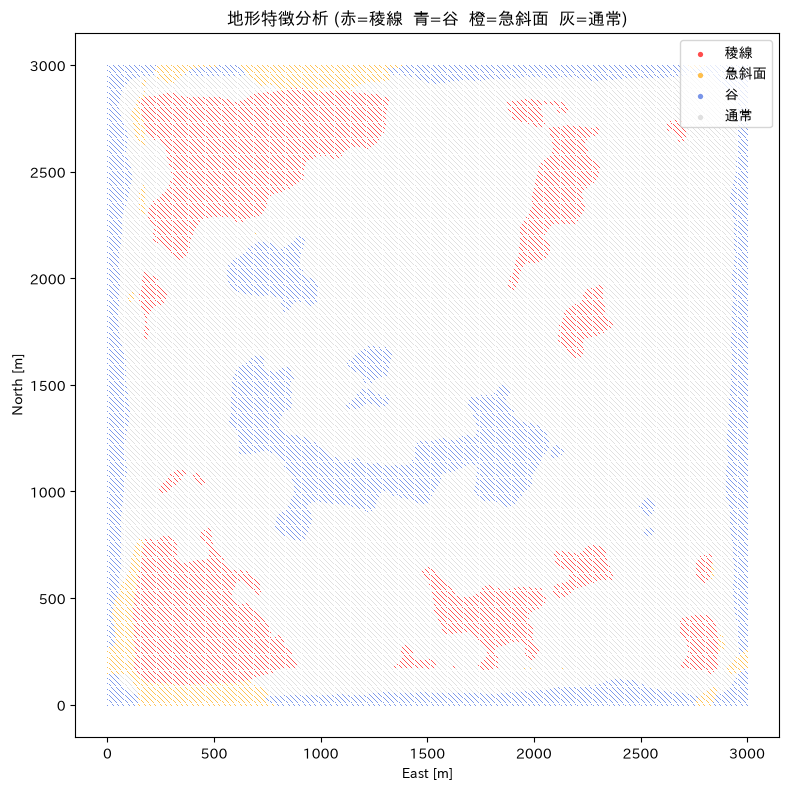

In [4]:
# ============================================================
# Cell 3: 地形解析 + 地形特徴の2D可視化
#   ※ 3D可視化は下部のコメントアウト欄を解除して使用
# ============================================================
import matplotlib.pyplot as plt
import japanize_matplotlib  # 日本語フォント自動設定
import numpy as np
from scripts.camera_optimizer import TerrainAnalyzer, CameraConfig

config = CameraConfig(
    n_poles=N_POLES,
    fixed_per_pole=FIXED_PER_POLE,
    ptz_per_pole=PTZ_PER_POLE,
    pole_height_min=POLE_HEIGHT_MIN,
    pole_height_max=POLE_HEIGHT_MAX,
    fx=FX, fy=FY, image_width=IMAGE_W, image_height=IMAGE_H,
    fixed_tilt_deg=FIXED_TILT_DEG,
    fixed_fov_h=FIXED_FOV_H,
    ptz_fov_h=PTZ_FOV_H,
    max_visibility_range=MAX_VIS_RANGE,
    slope_threshold_deg=SLOPE_THRESHOLD_DEG,
    ridge_percentile=RIDGE_PERCENTILE,
    valley_percentile=VALLEY_PERCENTILE,
    n_ray_samples=N_RAY_SAMPLES,
    sa_iterations=SA_ITERATIONS,
    zone_weights=ZONE_WEIGHTS,
    fence_zone_width=FENCE_ZONE_WIDTH,
    building_zone_radius=BUILDING_ZONE_RADIUS,
)

analyzer    = TerrainAnalyzer(mesh, config)
ridge_mask  = analyzer.detect_ridges()
valley_mask = analyzer.detect_valleys()
steep_mask  = analyzer.detect_steep_slopes()

print(f"稜線頂点数 : {ridge_mask.sum():,} / {len(verts):,}")
print(f"谷底頂点数 : {valley_mask.sum():,}")
print(f"急斜面頂点 : {steep_mask.sum():,}  (>{SLOPE_THRESHOLD_DEG}°)")
print(f"ポール高さ : 平地={POLE_HEIGHT_MAX}m  急斜面={POLE_HEIGHT_MIN}m (傾斜で線形補間)")

# ── 2D特徴マップ (軽量) ──────────────────────────────────────
# 間引き (描画速度のため)
step = 5
sv = verts[::step]
rm = ridge_mask[::step]
vm = valley_mask[::step]
sm = steep_mask[::step]

base_color = np.where(rm, 0, np.where(sm, 1, np.where(vm, 2, 3)))
cmap_colors = ['red', 'orange', 'royalblue', 'lightgray']
labels      = ['稜線', '急斜面', '谷', '通常']

fig, ax = plt.subplots(figsize=(10, 8))
for idx, (color, label) in enumerate(zip(cmap_colors, labels)):
    mask = (base_color == idx)
    if mask.any():
        ax.scatter(sv[mask,0], sv[mask,1], c=color, s=0.4,
                   label=label, alpha=0.7, linewidths=0)
ax.set_xlabel('East [m]'); ax.set_ylabel('North [m]')
ax.set_title('地形特徴分析 (赤=稜線  青=谷  橙=急斜面  灰=通常)')
ax.set_aspect('equal')
ax.legend(markerscale=6, loc='upper right')
plt.tight_layout()
plt.show()
plt.close(fig)  # メモリ解放

# ─────────────────────────────────────────────────────────────
# 【3D可視化 — 重いので必要時のみコメントアウト解除】
# import plotly.graph_objects as go
# step3d = 5
# sv3 = verts[::step3d]
# colors_3d = np.full(len(sv3), 'lightgray', dtype=object)
# colors_3d[ridge_mask[::step3d]]  = 'red'
# colors_3d[valley_mask[::step3d]] = 'blue'
# colors_3d[steep_mask[::step3d]]  = 'orange'
# fig3d = go.Figure(data=[go.Scatter3d(
#     x=sv3[:,0], y=sv3[:,1], z=sv3[:,2],
#     mode='markers', marker=dict(size=1.5, color=colors_3d),
#     name='地形特徴',
# )])
# fig3d.update_layout(
#     title="地形特徴分析 (赤=稜線  青=谷  橙=急斜面)",
#     scene=dict(aspectmode='data'), width=900, height=600,
# )
# fig3d.show()
# ─────────────────────────────────────────────────────────────


In [ ]:
# ============================================================
# Cell 4: 正解点群生成
#   GT_N_POINTS は Cell 1 で設定 (デフォルト 100,000)
#   open3d 不要 (trimesh のみで完結) — メモリ消費を抑えるため
# ============================================================
from scripts.terrain_loader import mesh_to_pointcloud
import trimesh

pts = mesh_to_pointcloud(mesh, n_points=GT_N_POINTS, return_numpy=True)
cloud = trimesh.points.PointCloud(pts)
cloud.export(str(GT_PLY))
print(f"GT pointcloud saved: {GT_PLY}  ({len(pts):,} pts)")


GT pointcloud saved: cases/ranch_01/terrain_gt.ply  (100,000 pts)


: 

In [ ]:
# ============================================================
# Cell 5: 3次元観測点(ポール)配置最適化
# ============================================================
from scripts.camera_optimizer import CameraOptimizer, FarmBoundary
import json, time

# farm_boundary.json があればゾーン制御を有効化
farm, buildings = None, None
if FARM_BOUNDARY_JSON.exists():
    try:
        farm, buildings = FarmBoundary.load_from_json(FARM_BOUNDARY_JSON)
        print(f"農場境界読み込み: {FARM_BOUNDARY_JSON}")
        print(f"  建物マップ: {'あり' if buildings else 'なし'}")
    except ImportError as e:
        print(f"警告: {e} — BBoxフォールバックで実行")
else:
    print("farm_boundary.json なし → BBoxフォールバックモード (ゾーン 1/2/3)")

optimizer = CameraOptimizer(mesh, config, farm=farm, buildings=buildings)

print(f"\n最適化開始: {N_POLES} ポール × ({FIXED_PER_POLE}固定+{PTZ_PER_POLE}PTZ) = {N_CAMERAS_TOTAL} カメラ")
print(f"焼きなまし {SA_ITERATIONS} iter ...")
t0    = time.time()
poles = optimizer.optimize()
print(f"完了: {time.time()-t0:.1f}s")

# JSON 保存
poses_dict = optimizer.to_json(poles, CASE_NAME)
with open(POSES_JSON, 'w') as f:
    json.dump(poses_dict, f, indent=2)
print(f"Saved: {POSES_JSON}")

# サマリー
all_cams = [c for p in poles for c in p.cameras]
n_fixed  = sum(1 for c in all_cams if c.type == 'fixed')
n_ptz    = sum(1 for c in all_cams if c.type == 'ptz')
zones    = sorted(set(p.zone for p in poles))
print(f"\n配置結果:")
print(f"  観測点(ポール) : {len(poles)} 本")
print(f"  固定カメラ合計 : {n_fixed} 台")
print(f"  PTZカメラ合計  : {n_ptz} 台")
for zone in zones:
    n = sum(1 for p in poles if p.zone == zone)
    label = {"A":"農場外(配置なし)","B":"フェンス帯","C":"内部","D":"建物周辺",
             "1":"外周","2":"中間","3":"中心"}.get(zone, zone)
    print(f"  Zone {zone} ({label}): {n} ポール")

農場境界読み込み: cases/ranch_01/farm_boundary.json
  建物マップ: なし

最適化開始: 15 ポール × (4固定+2PTZ) = 90 カメラ
焼きなまし 500 iter ...


In [ ]:
# ============================================================
# Cell 6: 3D可視化 (plotly)
#   ※ フルメッシュ(数十万面)を直接Mesh3dに渡すとノートブック出力が
#     肥大化し、Jupyterサーバーがメモリ不足で落ちることがあるため、
#     地形は間引いた点群(Scatter3d)として描画する。
# ============================================================
import plotly.graph_objects as go
import numpy as np

terrain_step = max(1, len(verts) // 50_000)  # 描画点数を ~5万点以下に抑える
sv3d = verts[::terrain_step]

traces = [go.Scatter3d(
    x=sv3d[:,0], y=sv3d[:,1], z=sv3d[:,2],
    mode='markers',
    marker=dict(size=1.5, color=sv3d[:,2], colorscale='earth', opacity=0.5),
    name='地形', showlegend=False,
)]

# ゾーン色マップ: A/B/C/D (農場境界あり) + 1/2/3 (フォールバック)
zone_color_map = {
    "A": "gray",    # 農場外 (通常は配置されないが念のため)
    "B": "yellow",  # フェンス帯
    "C": "orange",  # 内部
    "D": "purple",  # 建物周辺
    "1": "yellow",  # フォールバック外周
    "2": "orange",  # フォールバック中間
    "3": "red",     # フォールバック中心
}

# ポール柱を線で描画
for pole in poles:
    g = pole.position_ground
    t = pole.top_position
    color = zone_color_map.get(str(pole.zone), 'white')
    traces.append(go.Scatter3d(
        x=[g[0],t[0]], y=[g[1],t[1]], z=[g[2],t[2]],
        mode='lines', line=dict(color=color, width=4), showlegend=False,
    ))

# ポール頂部マーカー
tops        = np.array([p.top_position for p in poles])
zone_colors = [zone_color_map.get(str(p.zone), 'white') for p in poles]
traces.append(go.Scatter3d(
    x=tops[:,0], y=tops[:,1], z=tops[:,2],
    mode='markers+text',
    marker=dict(size=6, color=zone_colors, symbol='square'),
    text=[f"P{p.id}" for p in poles],
    textposition='top center',
    name='観測点(ポール)',
))

# 固定カメラの視線 (先頭5ポール × 固定カメラのみ)
for pole in poles[:5]:
    for cam in pole.cameras:
        if cam.type != 'fixed':
            continue
        fwd = cam.lookat - cam.position
        fwd /= np.linalg.norm(fwd) + 1e-9
        tip = cam.position + fwd * 40.0
        traces.append(go.Scatter3d(
            x=[cam.position[0], tip[0]],
            y=[cam.position[1], tip[1]],
            z=[cam.position[2], tip[2]],
            mode='lines', line=dict(color='cyan', width=1),
            showlegend=False,
        ))

# ゾーン凡例テキスト (farm あり/なしで切り替え)
if farm is not None:
    zone_legend = "灰=A(外) 黄=B(フェンス) 橙=C(内部) 紫=D(建物)"
else:
    zone_legend = "黄=Zone1(外周) 橙=Zone2(中間) 赤=Zone3(中心)"

fig = go.Figure(data=traces)
fig.update_layout(
    title=f"観測点配置 3D: {N_POLES}ポール / {N_CAMERAS_TOTAL}カメラ  ({zone_legend})",
    scene=dict(aspectmode='data',
               xaxis_title='East [m]', yaxis_title='North [m]', zaxis_title='Up [m]'),
    width=1000, height=700,
)
fig.show()
del sv3d  # 大きな配列を明示的に解放


In [ ]:
# ============================================================
# Cell 7: 2D俯瞰マップ — 観測点位置 + カメラ視野扇形
#
# 地形をXY平面に投影し、各ポールの位置と
# カメラごとの視野角を扇形(Wedge)で描画する。
# 固定カメラ=青扇形、PTZ=赤扇形。
# ゾーン色: A=灰 / B=黄 / C=橙 / D=紫 (農場境界ありの場合)
#            1=黄 / 2=橙 / 3=赤 (BBoxフォールバック)
# ============================================================
import matplotlib.pyplot as plt
import japanize_matplotlib  # 日本語フォント自動設定
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge
from matplotlib.collections import PatchCollection
import numpy as np

fig, ax = plt.subplots(figsize=(14, 12))
ax.set_aspect('equal')

# ── 地形の高さをXY投影してヒートマップ表示 ───────────────────────────────────
sc = ax.scatter(
    verts[:,0], verts[:,1],
    c=verts[:,2], cmap='terrain',
    s=0.3, alpha=0.6, zorder=1,
)
plt.colorbar(sc, ax=ax, label='標高 [m]', shrink=0.6)

# ── カメラ視野扇形の描画 ─────────────────────────────────────────────────────
VIS_RANGE = MAX_VIS_RANGE

fixed_wedges = []
ptz_wedges   = []

for pole in poles:
    px, py = pole.position_ground[0], pole.position_ground[1]

    for cam in pole.cameras:
        az  = cam.azimuth_deg     # 北=0, 東=90 (方位角)
        fov = cam.fov_h

        # matplotlib Wedge 角度: East=0, 反時計回り
        # 方位角 az (北基準CW) → matplotlib角度 (東基準CCW) に変換
        mpl_center_deg = 90.0 - az
        theta1 = mpl_center_deg - fov / 2
        theta2 = mpl_center_deg + fov / 2

        wedge = Wedge(center=(px, py), r=VIS_RANGE, theta1=theta1, theta2=theta2)
        if cam.type == 'fixed':
            fixed_wedges.append(wedge)
        else:
            ptz_wedges.append(wedge)

if fixed_wedges:
    ax.add_collection(PatchCollection(
        fixed_wedges, alpha=0.10, facecolor='steelblue',
        edgecolor='steelblue', linewidth=0.4, zorder=2,
    ))
if ptz_wedges:
    ax.add_collection(PatchCollection(
        ptz_wedges, alpha=0.12, facecolor='tomato',
        edgecolor='tomato', linewidth=0.4, zorder=2,
    ))

# ── 農場境界ポリゴンの描画 (存在する場合) ────────────────────────────────────
if farm is not None:
    bnd = farm._coords
    ax.plot(bnd[:,0], bnd[:,1], color='lime', linewidth=2.0,
            linestyle='--', zorder=4, label='農場境界')

# ── 観測点(ポール)マーカー ───────────────────────────────────────────────────
zone_palette = {
    "A": "#888888",   # 灰
    "B": "#f5c518",   # 黄
    "C": "#ff8c00",   # 橙
    "D": "#9b59b6",   # 紫
    "1": "#f5c518",   # フォールバック: 外周=黄
    "2": "#ff8c00",   # フォールバック: 中間=橙
    "3": "#cc0000",   # フォールバック: 中心=赤
}

for pole in poles:
    px, py = pole.position_ground[0], pole.position_ground[1]
    color  = zone_palette.get(str(pole.zone), 'gray')

    ax.scatter(px, py, s=120, marker='s', color=color,
               edgecolors='black', linewidths=0.8, zorder=5)

    ax.annotate(
        f"P{pole.id}\n({FIXED_PER_POLE}F+{PTZ_PER_POLE}P)",
        (px, py), fontsize=6.5, ha='center', va='bottom',
        xytext=(0, 5), textcoords='offset points', zorder=6,
        color='white',
        bbox=dict(boxstyle='round,pad=0.2', fc=color, alpha=0.8, lw=0),
    )

# ── 凡例 ────────────────────────────────────────────────────────────────────
legend_elems = [
    mpatches.Patch(fc='steelblue', alpha=0.4, label=f'固定カメラ視野 (FOV {FIXED_FOV_H}°)'),
    mpatches.Patch(fc='tomato',    alpha=0.4, label=f'PTZ視野 (FOV {PTZ_FOV_H}°)'),
]
if farm is not None:
    legend_elems += [
        mpatches.Patch(fc='#888888', ec='black', label='Zone A (農場外)'),
        mpatches.Patch(fc='#f5c518', ec='black', label='Zone B (フェンス帯)'),
        mpatches.Patch(fc='#ff8c00', ec='black', label='Zone C (内部)'),
        mpatches.Patch(fc='#9b59b6', ec='black', label='Zone D (建物周辺)'),
        mpatches.Patch(fc='none', ec='lime', linestyle='--', label='農場境界'),
    ]
else:
    legend_elems += [
        mpatches.Patch(fc='#f5c518', ec='black', label='Zone 1 (外周)'),
        mpatches.Patch(fc='#ff8c00', ec='black', label='Zone 2 (中間)'),
        mpatches.Patch(fc='#cc0000', ec='black', label='Zone 3 (中心)'),
    ]

ax.legend(handles=legend_elems, loc='upper right', fontsize=8, framealpha=0.85)

ax.set_xlabel('East [m]', fontsize=11)
ax.set_ylabel('North [m]', fontsize=11)
ax.set_title(
    f"観測点配置 2D俯瞰マップ — {CASE_NAME}\n"
    f"{N_POLES}ポール × ({FIXED_PER_POLE}固定+{PTZ_PER_POLE}PTZ) = {N_CAMERAS_TOTAL}台"
    f"  /  可視半径={VIS_RANGE}m",
    fontsize=12,
)
ax.grid(True, alpha=0.25)

# 北方向矢印
xlim, ylim = ax.get_xlim(), ax.get_ylim()
arrow_x = xlim[0] + (xlim[1]-xlim[0]) * 0.05
arrow_y = ylim[0] + (ylim[1]-ylim[0]) * 0.08
ax.annotate('N', xy=(arrow_x, arrow_y + (ylim[1]-ylim[0])*0.06),
            xytext=(arrow_x, arrow_y),
            arrowprops=dict(arrowstyle='->', color='white', lw=2),
            fontsize=13, color='white', ha='center', fontweight='bold')

plt.tight_layout()
out_path = CASE_DIR / "observation_map_2d.png"
plt.savefig(str(out_path), dpi=180, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
plt.close(fig)  # メモリ解放
print(f"保存: {out_path}")

In [ ]:
# ============================================================
# Cell 8: カバレッジ分析
#   カメラをバッチ処理して中間配列のメモリを都度解放する
# ============================================================
import matplotlib.pyplot as plt
import japanize_matplotlib  # 日本語フォント自動設定
import numpy as np

all_cams = [c for p in poles for c in p.cameras]
visibility_count = np.zeros(len(verts), dtype=np.int16)

BATCH = 10  # 一度に処理するカメラ数 (メモリ節約)
for batch_start in range(0, len(all_cams), BATCH):
    batch = all_cams[batch_start:batch_start + BATCH]
    for cam in batch:
        diffs = verts - cam.position          # (N,3)
        dists = np.linalg.norm(diffs, axis=1) # (N,)
        fwd   = cam.lookat - cam.position
        fwd  /= np.linalg.norm(fwd) + 1e-9
        dot   = diffs @ fwd / (dists + 1e-9)
        visible = (dists < MAX_VIS_RANGE) & (dot > 0.25)
        visibility_count[visible] += 1
        del diffs, dists, dot, visible        # 明示的解放

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(verts[:,0], verts[:,1],
                      c=visibility_count, cmap='YlOrRd', s=0.5, vmin=0)
plt.colorbar(sc, ax=axes[0], label='可視カメラ数')
pole_pts = np.array([p.position_ground for p in poles])
axes[0].scatter(pole_pts[:,0], pole_pts[:,1],
                c='white', marker='s', s=60, edgecolors='black',
                linewidths=0.8, label='観測点', zorder=5)
axes[0].set_title('カバレッジマップ (XY投影)')
axes[0].set_xlabel('East [m]'); axes[0].set_ylabel('North [m]')
axes[0].set_aspect('equal'); axes[0].legend()

axes[1].hist(visibility_count, bins=30, color='steelblue', edgecolor='white')
axes[1].set_xlabel('可視カメラ数'); axes[1].set_ylabel('頂点数')
axes[1].set_title('カバレッジ分布')
pct_zero = (visibility_count == 0).mean() * 100
axes[1].axvline(visibility_count.mean(), color='red', linestyle='--',
                label=f'平均={visibility_count.mean():.1f}')
axes[1].legend()
axes[1].text(0.98, 0.95, f'死角: {pct_zero:.1f}%',
             transform=axes[1].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='wheat'))

plt.tight_layout()
plt.savefig(str(CASE_DIR / "coverage_map.png"), dpi=150)
plt.show()
plt.close(fig)  # メモリ解放
print(f"平均カバレッジ: {visibility_count.mean():.2f} カメラ/頂点")
print(f"死角(0台): {pct_zero:.1f}%")


In [ ]:
# ============================================================
# Cell 9: COLMAPフォーマット変換 (COLMAP不要)
# ============================================================
from scripts.pose_exporter import export_colmap_format

export_colmap_format(
    poses_json=POSES_JSON,
    terrain_ply=TERRAIN_PLY,
    images_dir=CASE_DIR / "images",
    output_dir=COLMAP_DIR,
    n_points3d=100_000,
)
print(f"COLMAPフォーマット出力完了: {COLMAP_DIR}")

In [ ]:
# ============================================================
# Cell 10: データ整備 完了レポート
# ============================================================
import json

with open(POSES_JSON) as f:
    poses_data = json.load(f)

n_poles  = len(poses_data['poles'])
n_cams   = len(poses_data['cameras'])
n_fixed  = sum(1 for c in poses_data['cameras'] if c['type'] == 'fixed')
n_ptz    = sum(1 for c in poses_data['cameras'] if c['type'] == 'ptz')

est_render_sec = n_cams * 2
est_train_min  = 30

print("="*55)
print("データ整備 完了レポート")
print("="*55)
print(f"ケース名      : {CASE_NAME}")
print(f"地形ファイル  : {TERRAIN_PLY}")
print(f"観測点(ポール): {n_poles} 本")
print(f"カメラ総数    : {n_cams} 台 ({n_fixed}固定 + {n_ptz}PTZ)")
print(f"正解点群      : {GT_PLY}  ({GT_N_POINTS:,}pts)")
print(f"COLMAPデータ  : {COLMAP_DIR}")
print(f"2D俯瞰マップ  : {CASE_DIR}/observation_map_2d.png")
print()
print("【次のステップ】")
print(f"  python run_simulation.py --case {CASE_NAME}")
print()
print("推定所要時間:")
print(f"  Genesisレンダリング: ~{est_render_sec//60}分")
print(f"  3DGSトレーニング   : ~{est_train_min}分 (GPU依存)")
print(f"  精度評価           : ~5分")